# Step 3-3. Black-Litterman Portfolio Optimization

**파이프라인**
1. 월별 리샘플링: `monthly_panel.csv` → 월말 기준 return / mcap 피벗
2. Walk-Forward 리밸런싱 (매월)
   - 유니버스: 시점별 **시총 상위 100종목** (lookahead 없음)
   - Prior: 시총 가중 균형 수익률 `π = δΣw_mkt`
   - View (Q): XGBoost OOS 예측값 (Step3-2에서 생성)
   - View 불확실성 (Ω): t 이전 OOS 잔차 분산
   - Posterior: Black-Litterman 수식 (절대적 뷰, P=I)
   - 최적화: MVO (투자자 성향별 γ)
3. 성과 분석: 누적 수익률, Sharpe, MDD, 비중 히트맵

**시점 누수 방지 체크리스트**
| 입력 | 사용 시점 | 안전 여부 |
|---|---|---|
| 시총 (log_mcap) | 리밸런싱 월 t | ✅ 당월 말 정보 |
| XGB 예측 (Q) | 리밸런싱 월 t (OOS) | ✅ Step3-2에서 이미 OOS 보장 |
| 공분산 (Σ) | 과거 36개월 수익률 [t-36, t-1] | ✅ 미래 수익률 미사용 |
| Omega (Ω) | t 이전 OOS 잔차 분산 | ✅ 미래 잔차 미사용 |
| 포트폴리오 수익률 | fwd_excess_ret_1m[t] (평가용) | ✅ 가중치 결정 후 실현 수익 |

---
## Section 1. 설정 & 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

# 한글 폰트
for _fp in fm.findSystemFonts(fontext='ttf'):
    if 'malgun' in _fp.lower() or 'nanum' in _fp.lower():
        plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

# ── 파라미터 ──────────────────────────────────────────────────────────────
TOP_N            = 100     # 시총 상위 종목 수
MIN_HIST_MONTHS  = 36      # 공분산 추정 최소 기간 (월)
DELTA            = 2.5     # 시장 위험 회피 계수
TAU              = 0.05    # View 신뢰도 (BL tau)
W_MAX            = 0.10    # 단일 종목 최대 비중
TC               = 10 / 10_000  # 거래비용 (왕복 10bps)

GAMMAS = {'공격형': 1.0, '중립형': 3.0, '보수형': 8.0}

DATA_DIR   = Path('data')
STEP3_DIR  = Path('outputs/step2_xgb')
OUTPUT_DIR = Path('outputs/step3_bl')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('설정 완료')
print(f'  TOP_N={TOP_N}, MIN_HIST={MIN_HIST_MONTHS}개월, τ={TAU}, W_MAX={W_MAX:.0%}')

설정 완료
  TOP_N=100, MIN_HIST=36개월, τ=0.05, W_MAX=10%


---
## Section 2. 데이터 로드 & 월별 리샘플링

패널 데이터는 한 달에 여러 날짜가 존재하므로 **월별 마지막 날짜**를 기준으로 피벗.

In [2]:
# ── 원본 패널 로드 ─────────────────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', index_col='date', parse_dates=True)
panel = panel.sort_index()

# ── OOS 예측 로드 (Step3-2 walk-forward 결과) ─────────────────────────────
oos_raw = pd.read_csv(STEP3_DIR / 'oos_predictions.csv', index_col='date', parse_dates=True)
oos_raw = oos_raw.sort_index()

# ── 월별 리샘플링: 각 (월, 종목)의 마지막 날짜 선택 ─────────────────────────
def resample_to_monthly(df, value_cols):
    tmp = df.reset_index().copy()
    tmp['month'] = tmp['date'].dt.to_period('M')
    monthly = (
        tmp.sort_values('date')
        .groupby(['month', 'ticker'])
        .last()
        .reset_index()
    )
    pivots = {}
    for col in value_cols:
        pivots[col] = monthly.pivot(index='month', columns='ticker', values=col)
    return pivots

# 패널: 수익률 + 시총
panel_pivots = resample_to_monthly(
    panel[['ticker', 'fwd_excess_ret_1m', 'log_mcap']],
    value_cols=['fwd_excess_ret_1m', 'log_mcap']
)
ret_pivot  = panel_pivots['fwd_excess_ret_1m']   # shape: (months, tickers)
mcap_pivot = panel_pivots['log_mcap']             # shape: (months, tickers)

# OOS 예측: 예측값 + 잔차
oos_pivots = resample_to_monthly(
    oos_raw[['ticker', 'pred', 'resid']],
    value_cols=['pred', 'resid']
)
pred_pivot  = oos_pivots['pred']    # shape: (months, tickers) — NaN이면 해당 월 OOS 없음
resid_pivot = oos_pivots['resid']   # shape: (months, tickers)

print(f'ret_pivot  : {ret_pivot.shape}  ({ret_pivot.index.min()} ~ {ret_pivot.index.max()})')
print(f'mcap_pivot : {mcap_pivot.shape}')
print(f'pred_pivot : {pred_pivot.shape}  ({pred_pivot.index.min()} ~ {pred_pivot.index.max()})')

# 리밸런싱 가능 월: OOS 예측이 있는 월만 (TOP_N 종목 이상 예측 보유)
n_pred_per_month = pred_pivot.notna().sum(axis=1)
rebal_months = n_pred_per_month[n_pred_per_month >= TOP_N].index
print(f'\n리밸런싱 가능 월: {len(rebal_months)}개  ({rebal_months.min()} ~ {rebal_months.max()})')

ret_pivot  : (263, 628)  (2004-01 ~ 2025-11)
mcap_pivot : (263, 628)
pred_pivot : (187, 587)  (2010-01 ~ 2025-11)

리밸런싱 가능 월: 187개  (2010-01 ~ 2025-11)


---
## Section 3. 헬퍼 함수

In [3]:
def estimate_cov(ret_df: pd.DataFrame) -> np.ndarray:
    """Ledoit-Wolf shrinkage 공분산 (월별 단위, annualize 안 함)."""
    clean = ret_df.ffill().fillna(0)
    lw = LedoitWolf().fit(clean.values)
    return lw.covariance_


def bl_posterior(
    Q: np.ndarray,
    Omega: np.ndarray,
    cov: np.ndarray,
    pi: np.ndarray,
    tau: float
):
    """
    절대적 뷰 (P = I) Black-Litterman posterior.

    μ_BL = [(τΣ)^{-1} + Ω^{-1}]^{-1} [(τΣ)^{-1}π + Ω^{-1}Q]
    Σ_BL = Σ + [(τΣ)^{-1} + Ω^{-1}]^{-1}
    """
    inv_tau_cov = np.linalg.inv(tau * cov)
    inv_omega   = np.linalg.inv(Omega)
    M    = np.linalg.inv(inv_tau_cov + inv_omega)
    mu   = M @ (inv_tau_cov @ pi + inv_omega @ Q)
    cov_bl = cov + M
    return mu, cov_bl


def mvo_optimize(
    mu: np.ndarray,
    cov: np.ndarray,
    gamma: float,
    w_max: float = W_MAX
) -> np.ndarray:
    """max w'μ - (γ/2)w'Σw  s.t. sum=1, 0≤w≤w_max"""
    n  = len(mu)
    w0 = np.ones(n) / n

    def obj(w):
        return -(w @ mu - (gamma / 2) * (w @ cov @ w))

    res = minimize(
        obj, w0, method='SLSQP',
        bounds=[(0.0, w_max)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
        options={'ftol': 1e-12, 'maxiter': 500}
    )
    return res.x if res.success else w0


def portfolio_metrics(rets: pd.Series) -> dict:
    """월별 수익률 → 연율화 성과지표."""
    ann_ret = rets.mean() * 12
    ann_vol = rets.std()  * sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-12 else np.nan
    cum     = (1 + rets).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'Ann.Return': ann_ret, 'Ann.Vol': ann_vol, 'Sharpe': sharpe, 'MDD': mdd}


print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


---
## Section 4. Walk-Forward Black-Litterman 백테스트

**리밸런싱 로직 (매월 t)**
```
1. 유니버스 = 시총 상위 100종목 (mcap_pivot[t])
2. 공분산 Σ = Ledoit-Wolf( ret_pivot[t-36:t-1] )   ← 미래 정보 없음
3. Prior π = δ × Σ × w_mkt  (시총 가중)
4. View Q = pred_pivot[t]  (XGBoost OOS 예측)
5. View 불확실성 Ω = diag( var(resid_pivot[:t-1]) )  ← 미래 잔차 없음
6. BL posterior → MVO → 비중 w
7. 포트폴리오 수익률 = w' × ret_pivot[t] − 거래비용
```

In [4]:
port_returns        = {g: [] for g in GAMMAS}
weight_history      = {g: [] for g in GAMMAS}
prev_weights        = {g: {} for g in GAMMAS}
view_weight_records = []
prior_post_records  = []

skipped = 0

for t in rebal_months:

    # ── 1. 유니버스: 시총 상위 TOP_N ─────────────────────────────────────
    mcap_t = mcap_pivot.loc[t].dropna()
    top100_tickers = mcap_t.nlargest(TOP_N).index.tolist()

    # ── 2. XGB 예측값 (Q) ────────────────────────────────────────────────
    q_raw = pred_pivot.loc[t, top100_tickers].dropna()
    if len(q_raw) < 20:
        skipped += 1
        continue
    universe = q_raw.index.tolist()

    # ── 3. 공분산 추정 ────────────────────────────────────────────────────
    past_months = ret_pivot.index[ret_pivot.index < t]
    hist_months = past_months[-MIN_HIST_MONTHS:]
    if len(hist_months) < MIN_HIST_MONTHS // 2:
        skipped += 1
        continue

    ret_hist = ret_pivot.loc[hist_months, universe]
    valid_mask = ret_hist.notna().sum() >= len(hist_months) // 2
    universe = ret_hist.columns[valid_mask].tolist()
    if len(universe) < 20:
        skipped += 1
        continue

    ret_hist = ret_hist[universe]
    cov = estimate_cov(ret_hist)

    # ── 4. 시총 가중 Prior ───────────────────────────────────────────────
    mcap_final = mcap_t.reindex(universe).fillna(mcap_t.min())
    cap_vals = np.exp(mcap_final.values)
    w_mkt = cap_vals / cap_vals.sum()
    pi = DELTA * cov @ w_mkt

    # ── 5. View 불확실성 Ω ────────────────────────────────────────────────
    past_resid = resid_pivot.loc[resid_pivot.index < t, universe]
    if len(past_resid) < 3:
        fallback_var = resid_pivot.stack().var()
        omega_diag = np.full(len(universe), max(fallback_var, 1e-6))
    else:
        omega_series = past_resid.var()
        global_mean_var = past_resid.stack().var()
        omega_diag = omega_series.fillna(global_mean_var).values
        omega_diag = np.maximum(omega_diag, 1e-8)
    Omega = np.diag(omega_diag)

    # ── View weight 진단: τΣ_ii / (τΣ_ii + Ω_ii) ────────────────────────
    tau_cov_diag = TAU * np.diag(cov)
    view_weights = tau_cov_diag / (tau_cov_diag + omega_diag)
    view_weight_records.append({
        'month':  t,
        'mean':   float(view_weights.mean()),
        'median': float(np.median(view_weights)),
        'min':    float(view_weights.min()),
        'max':    float(view_weights.max()),
    })

    # ── 6. BL Posterior + MVO (성향별) ───────────────────────────────────
    Q_vec = q_raw.reindex(universe).fillna(0).values

    try:
        mu_bl, cov_bl = bl_posterior(Q_vec, Omega, cov, pi, TAU)
    except np.linalg.LinAlgError:
        skipped += 1
        continue

    # Prior → Posterior 이동 크기 기록
    prior_post_records.append({
        'month':     t,
        'pi_mean':   float(pi.mean()),
        'mu_bl_mean': float(mu_bl.mean()),
        'shift':     float(np.abs(mu_bl - pi).mean()),
    })

    # ── 7. 포트폴리오 수익률 ──────────────────────────────────────────────
    ret_t = ret_pivot.loc[t, universe].fillna(0).values

    for gname, gamma in GAMMAS.items():
        w_opt = mvo_optimize(mu_bl, cov_bl, gamma)
        prev_w_vec = np.array([prev_weights[gname].get(tk, 0.0) for tk in universe])
        tc_cost = np.sum(np.abs(w_opt - prev_w_vec)) * TC
        port_ret = float(w_opt @ ret_t) - tc_cost
        port_returns[gname].append({'month': t, 'ret': port_ret})
        prev_weights[gname] = dict(zip(universe, w_opt))
        weight_history[gname].append({
            'month': t, 'tickers': universe, 'weights': w_opt
        })

print(f'백테스트 완료 (스킵: {skipped})')
print(f'리밸런싱 횟수: {len(port_returns["중립형"])}회')
if port_returns['중립형']:
    first = port_returns['중립형'][0]['month']
    last  = port_returns['중립형'][-1]['month']
    print(f'기간: {first} ~ {last}')

vw_df  = pd.DataFrame(view_weight_records).set_index('month')
pvp_df = pd.DataFrame(prior_post_records).set_index('month')
print(f'\n평균 view weight: {vw_df["mean"].mean():.4f}  '
      f'(0=prior만 따라감, 1=view가 결정)')

백테스트 완료 (스킵: 0)
리밸런싱 횟수: 187회
기간: 2010-01 ~ 2025-11

평균 view weight: 0.0575  (0=prior만 따라감, 1=view가 결정)


---
## Section 5. 성과 분석

In [5]:
# ── 월별 수익률 Series 생성 ────────────────────────────────────────────────
ret_series = {}
for gname in GAMMAS:
    df_r = pd.DataFrame(port_returns[gname]).set_index('month').sort_index()
    ret_series[gname] = df_r['ret']

# 공통 기간 산출
start_m = min(s.index.min() for s in ret_series.values())
end_m   = max(s.index.max() for s in ret_series.values())

# ── 벤치마크 1: 시총 가중 (상위 100 종목, 월별 리밸런싱) ─────────────────
bench_cap_rets = []
for t in ret_series['중립형'].index:
    mcap_t = mcap_pivot.loc[t].dropna().nlargest(TOP_N)
    universe_b = mcap_t.index.tolist()
    cap_vals_b = np.exp(mcap_t.values)
    w_cap = cap_vals_b / cap_vals_b.sum()
    ret_t_b = ret_pivot.loc[t, universe_b].fillna(0).values
    bench_cap_rets.append({'month': t, 'ret': float(w_cap @ ret_t_b)})
bench_cap = pd.DataFrame(bench_cap_rets).set_index('month')['ret']

# ── 벤치마크 2: 동일 가중 (상위 100 종목) ────────────────────────────────
bench_ew_rets = []
for t in ret_series['중립형'].index:
    universe_b = mcap_pivot.loc[t].dropna().nlargest(TOP_N).index.tolist()
    ret_t_b = ret_pivot.loc[t, universe_b].fillna(0).values
    bench_ew_rets.append({'month': t, 'ret': float(ret_t_b.mean())})
bench_ew = pd.DataFrame(bench_ew_rets).set_index('month')['ret']

# ── 성과지표 테이블 ────────────────────────────────────────────────────────
rows = []
for gname, s in ret_series.items():
    m = portfolio_metrics(s)
    m['Strategy'] = f'BL-{gname}'
    rows.append(m)

m_cap = portfolio_metrics(bench_cap)
m_cap['Strategy'] = '시총가중 Benchmark'
rows.append(m_cap)

m_ew = portfolio_metrics(bench_ew)
m_ew['Strategy'] = '동일가중 Benchmark'
rows.append(m_ew)

perf_df = pd.DataFrame(rows).set_index('Strategy')[['Ann.Return', 'Ann.Vol', 'Sharpe', 'MDD']]
perf_pct = perf_df.copy()
perf_pct[['Ann.Return', 'Ann.Vol', 'MDD']] *= 100

print('=== 포트폴리오 성과 요약 ===')
print(perf_pct.round(2).to_string())

=== 포트폴리오 성과 요약 ===
                Ann.Return  Ann.Vol  Sharpe    MDD
Strategy                                          
BL-공격형               17.19    21.44    0.80 -35.77
BL-중립형               14.45    16.99    0.85 -29.63
BL-보수형               10.85    12.99    0.83 -24.90
시총가중 Benchmark       15.38    14.87    1.03 -22.88
동일가중 Benchmark       13.20    14.23    0.93 -20.10


=== Omega 진단: View가 Prior를 얼마나 바꾸는가 ===

View weight = τΣ_ii / (τΣ_ii + Ω_ii)
  → 0 : prior(π)만 따라감  |  1 : view(Q)가 posterior 결정

전체 기간 평균 view weight : 0.0575
전체 기간 중앙값 view weight: 0.0536
최솟값 (가장 보수적 시점)  : 0.0113
최댓값 (가장 공격적 시점)  : 0.9902

△  View weight ∈ [0.05, 0.20] → Prior가 지배적. 뷰 영향 제한적

Prior→Posterior 평균 이동: 10.41% (연율화)
  → 이 값이 0에 가까우면 BL이 prior를 거의 그대로 유지하는 것


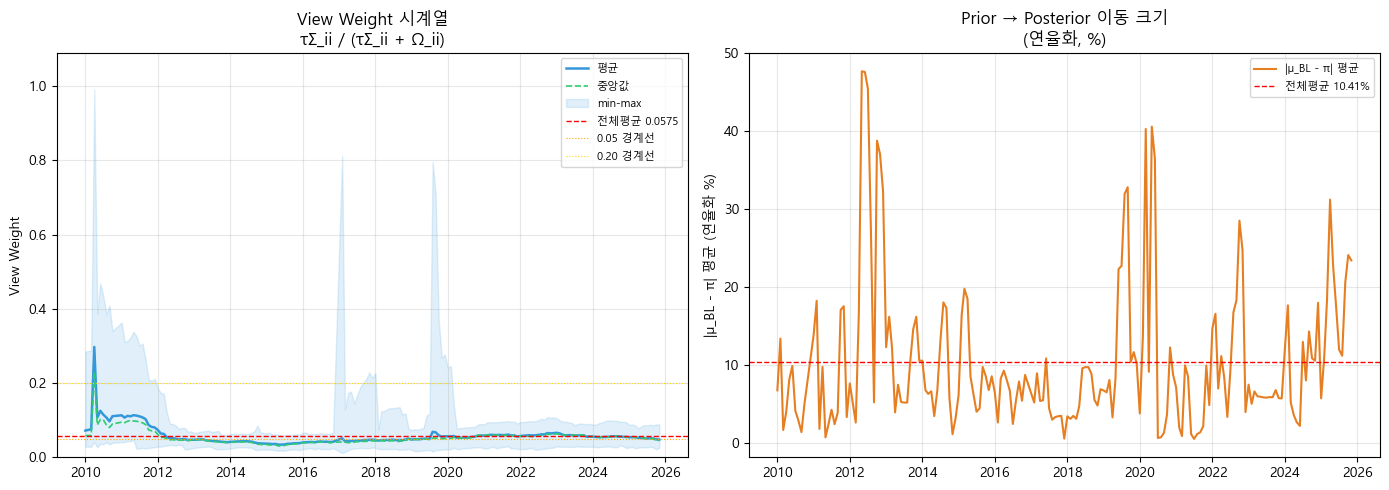

In [6]:
# ── Omega 진단: Prior vs View 영향도 ─────────────────────────────────────
mean_vw = vw_df['mean'].mean()

print('=== Omega 진단: View가 Prior를 얼마나 바꾸는가 ===')
print()
print('View weight = τΣ_ii / (τΣ_ii + Ω_ii)')
print('  → 0 : prior(π)만 따라감  |  1 : view(Q)가 posterior 결정')
print()
print(f'전체 기간 평균 view weight : {mean_vw:.4f}')
print(f'전체 기간 중앙값 view weight: {vw_df["median"].mean():.4f}')
print(f'최솟값 (가장 보수적 시점)  : {vw_df["min"].min():.4f}')
print(f'최댓값 (가장 공격적 시점)  : {vw_df["max"].max():.4f}')
print()

if mean_vw < 0.05:
    verdict = '⚠  View weight < 0.05 → 모델 예측이 거의 무시됨. TAU 증가 또는 Omega 재조정 필요'
elif mean_vw < 0.2:
    verdict = '△  View weight ∈ [0.05, 0.20] → Prior가 지배적. 뷰 영향 제한적'
elif mean_vw < 0.6:
    verdict = '✓  View weight ∈ [0.20, 0.60] → Prior와 View가 균형있게 반영됨'
else:
    verdict = '✓  View weight > 0.60 → View(Q)가 Posterior를 강하게 결정'
print(verdict)
print()

# Prior → Posterior 이동 크기 (연율화)
shift_ann = pvp_df['shift'] * 12 * 100
print(f'Prior→Posterior 평균 이동: {shift_ann.mean():.2f}% (연율화)')
print(f'  → 이 값이 0에 가까우면 BL이 prior를 거의 그대로 유지하는 것')

# ── 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) View weight 시계열
vw_ts = vw_df.index.to_timestamp()
axes[0].plot(vw_ts, vw_df['mean'],   color='#3498db', lw=1.8, label='평균')
axes[0].plot(vw_ts, vw_df['median'], color='#2ecc71', lw=1.2, ls='--', label='중앙값')
axes[0].fill_between(vw_ts, vw_df['min'], vw_df['max'], alpha=0.15, color='#3498db', label='min-max')
axes[0].axhline(mean_vw, color='red', ls='--', lw=1, label=f'전체평균 {mean_vw:.4f}')
axes[0].axhline(0.05, color='orange', ls=':', lw=0.8, label='0.05 경계선')
axes[0].axhline(0.20, color='gold',   ls=':', lw=0.8, label='0.20 경계선')
axes[0].set_title('View Weight 시계열\nτΣ_ii / (τΣ_ii + Ω_ii)')
axes[0].set_ylabel('View Weight')
axes[0].set_ylim(0, max(0.1, vw_df['max'].max() * 1.1))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# (2) Prior(π) vs Posterior(μ_BL) 평균 이동 크기
pvp_ts = pvp_df.index.to_timestamp()
axes[1].plot(pvp_ts, shift_ann, color='#e67e22', lw=1.5, label='|μ_BL - π| 평균')
axes[1].axhline(shift_ann.mean(), color='red', ls='--', lw=1,
                label=f'전체평균 {shift_ann.mean():.2f}%')
axes[1].set_title('Prior → Posterior 이동 크기\n(연율화, %)')
axes[1].set_ylabel('|μ_BL - π| 평균 (연율화 %)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bl_omega_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6. 시각화

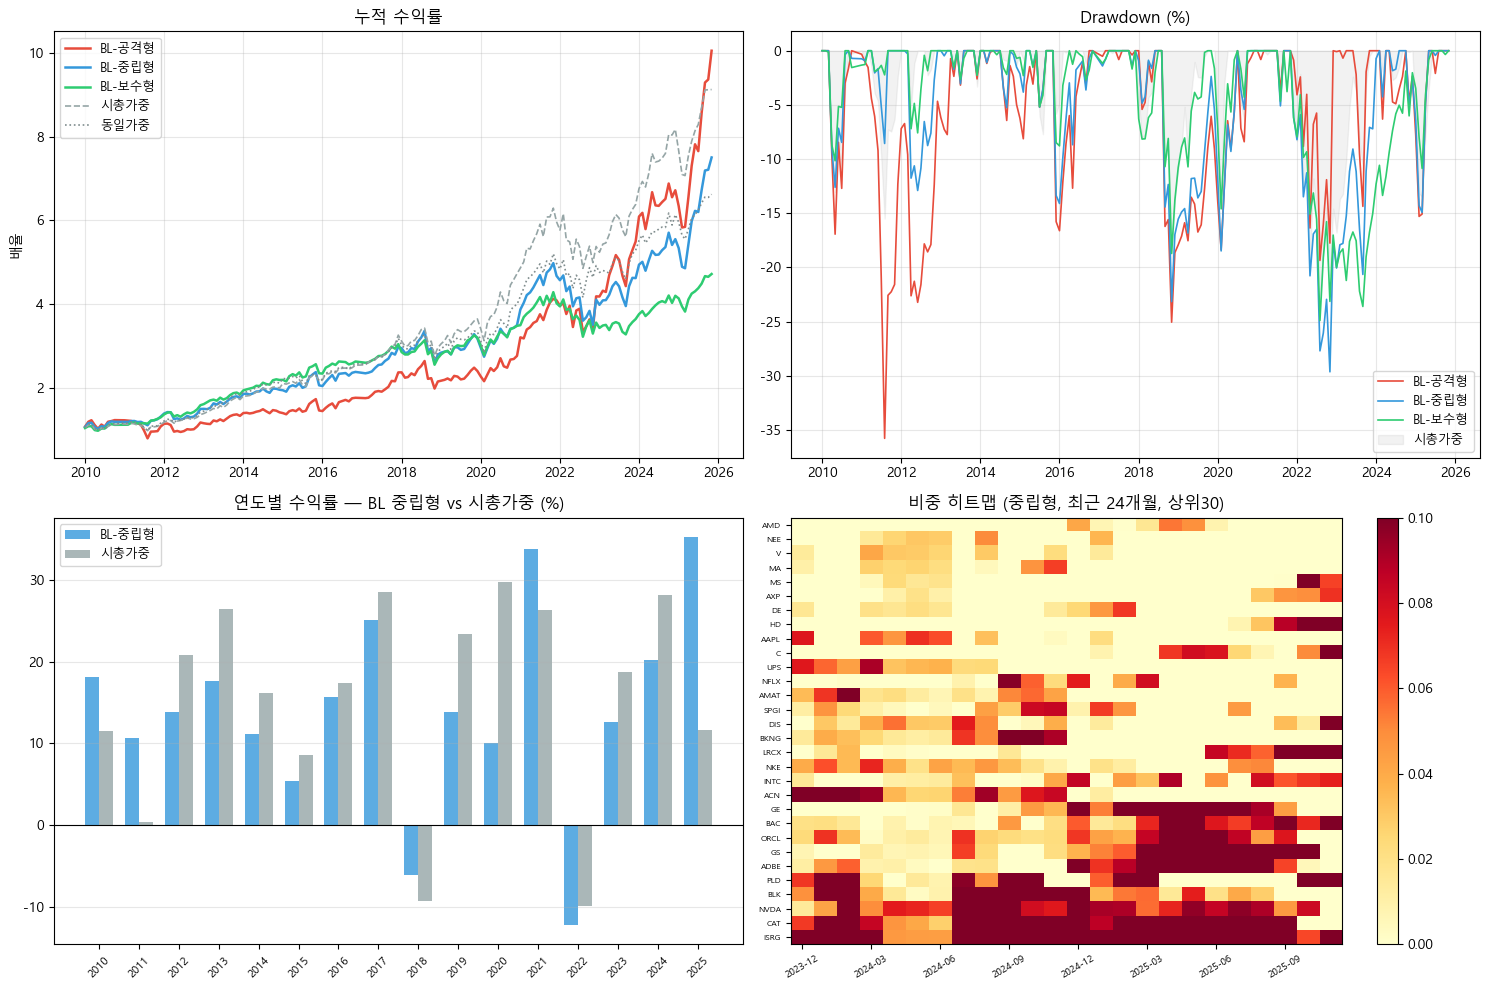

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
COLORS = {'공격형': '#e74c3c', '중립형': '#3498db', '보수형': '#2ecc71'}

# ── 누적 수익률 ─────────────────────────────────────────────────────────
ax1 = axes[0, 0]
for gname, s in ret_series.items():
    cum = (1 + s).cumprod()
    ax1.plot(cum.index.to_timestamp(), cum.values,
             label=f'BL-{gname}', color=COLORS[gname], lw=1.8)

bench_cum_cap = (1 + bench_cap).cumprod()
bench_cum_ew  = (1 + bench_ew).cumprod()
ax1.plot(bench_cum_cap.index.to_timestamp(), bench_cum_cap.values,
         label='시총가중', color='#95a5a6', lw=1.2, ls='--')
ax1.plot(bench_cum_ew.index.to_timestamp(), bench_cum_ew.values,
         label='동일가중', color='#7f8c8d', lw=1.2, ls=':')
ax1.set_title('누적 수익률')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('배율')

# ── Drawdown ─────────────────────────────────────────────────────────
ax2 = axes[0, 1]
for gname, s in ret_series.items():
    cum = (1 + s).cumprod()
    dd  = ((cum - cum.cummax()) / cum.cummax()) * 100
    ax2.plot(dd.index.to_timestamp(), dd.values,
             label=f'BL-{gname}', color=COLORS[gname], lw=1.2)
ax2.fill_between(
    bench_cum_cap.index.to_timestamp(),
    ((bench_cum_cap - bench_cum_cap.cummax()) / bench_cum_cap.cummax() * 100).values,
    0, alpha=0.1, color='gray', label='시총가중'
)
ax2.set_title('Drawdown (%)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── 연도별 수익률 (중립형 vs 시총가중 Benchmark) ──────────────────────
ax3 = axes[1, 0]
neutral = ret_series['중립형'].copy()
neutral.index = neutral.index.to_timestamp()
bench_cap_ts = bench_cap.copy()
bench_cap_ts.index = bench_cap_ts.index.to_timestamp()

annual_bl   = (neutral + 1).resample('YE').prod() - 1
annual_bm   = (bench_cap_ts + 1).resample('YE').prod() - 1

x = np.arange(len(annual_bl))
w_bar = 0.35
ax3.bar(x - w_bar/2, annual_bl.values * 100, w_bar,
        label='BL-중립형', color='#3498db', alpha=0.8)
ax3.bar(x + w_bar/2, annual_bm.reindex(annual_bl.index).values * 100, w_bar,
        label='시총가중', color='#95a5a6', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels([str(d.year) for d in annual_bl.index], rotation=45, fontsize=8)
ax3.axhline(0, color='k', lw=0.8)
ax3.set_title('연도별 수익률 — BL 중립형 vs 시총가중 (%)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# ── 최근 비중 히트맵 (중립형, 최근 24개월) ───────────────────────────
ax4 = axes[1, 1]
wh = weight_history['중립형'][-24:]
if wh:
    all_tickers = sorted(set(tk for rec in wh for tk in rec['tickers']))
    w_mat = np.zeros((len(wh), len(all_tickers)))
    for i, rec in enumerate(wh):
        tk_map = dict(zip(rec['tickers'], rec['weights']))
        for j, tk in enumerate(all_tickers):
            w_mat[i, j] = tk_map.get(tk, 0.0)

    # 평균 비중 상위 30 종목만 표시
    top30_idx = np.argsort(w_mat.mean(axis=0))[-30:]
    w_top = w_mat[:, top30_idx]
    top30_labels = [all_tickers[i] for i in top30_idx]

    im = ax4.imshow(w_top.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=W_MAX)
    ax4.set_yticks(range(len(top30_labels)))
    ax4.set_yticklabels(top30_labels, fontsize=6)
    month_labels = [str(rec['month']) for rec in wh]
    step = max(1, len(month_labels) // 8)
    ax4.set_xticks(range(0, len(month_labels), step))
    ax4.set_xticklabels(month_labels[::step], rotation=30, fontsize=7)
    ax4.set_title('비중 히트맵 (중립형, 최근 24개월, 상위30)')
    plt.colorbar(im, ax=ax4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bl_portfolio_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7. 결과 저장

In [8]:
# 성과 테이블
perf_pct.to_csv(OUTPUT_DIR / 'bl_performance.csv')

# 월별 수익률
rets_df = pd.DataFrame({
    **{f'BL-{g}': s for g, s in ret_series.items()},
    '시총가중': bench_cap,
    '동일가중': bench_ew,
})
rets_df.index = rets_df.index.to_timestamp()
rets_df.to_csv(OUTPUT_DIR / 'bl_monthly_returns.csv')

# 누적 수익률
cum_df = (1 + rets_df).cumprod()
cum_df.to_csv(OUTPUT_DIR / 'bl_cumulative_returns.csv')

# 비중 이력 (중립형)
w_rows = []
for rec in weight_history['중립형']:
    row = {'month': str(rec['month'])}
    row.update(dict(zip(rec['tickers'], rec['weights'])))
    w_rows.append(row)
pd.DataFrame(w_rows).set_index('month').to_csv(OUTPUT_DIR / 'bl_weights_neutral.csv')

print('저장 완료:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}')

저장 완료:
  bl_cumulative_returns.csv
  bl_monthly_returns.csv
  bl_omega_diagnostic.png
  bl_performance.csv
  bl_portfolio_summary.png
  bl_weights_neutral.csv
